# Wine Quality Prediction

## Objective

The objective of this project is to build and compare multiple machine learning
classification models for predicting wine quality based on its physicochemical
properties.

The original wine quality score ranges from 3 to 8 in this dataset.

The project will:

1. Load and inspect the Wine Quality dataset.
2. Explore the distribution of wine quality scores.
3. Perform Exploratory Data Analysis (EDA).
4. Plot the distributions of all chemical features.
5. Create a correlation heatmap.
6. Investigate class imbalance.
7. Convert the original quality score into three classes:
   - Low
   - Medium
   - High
8. Split the data using stratification.
9. Train three classifiers:
   - Random Forest
   - Stochastic Gradient Descent (SGD)
   - Support Vector Classifier (SVC)
10. Evaluate each model using:
    - Accuracy
    - Classification report
    - Confusion matrix
11. Identify important features using Random Forest.
12. Compare all three models.
13. Recommend the most suitable model for deployment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("WineQT.csv")

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (1143, 13)

Column names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               11

,Missing Values
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0



Duplicate rows: 0


In [3]:
print("First five rows:")
display(df.head())

First five rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


In [5]:
print("Descriptive statistics:")
display(df.describe())

Descriptive statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


## Inspect the Original Wine Quality Distribution

###  What?
Examine how frequently each original quality score occurs.

###  Why?
The task requires us to check whether some quality scores are
underrepresented.

### How?
We use `value_counts()` and visualize the distribution with a bar chart.

In [6]:
quality_counts = df["quality"].value_counts().sort_index()

print("Original quality distribution:")
display(quality_counts.to_frame("Count"))

Original quality distribution:


,Count
quality,
3,6
4,33
5,483
6,462
7,143
8,16


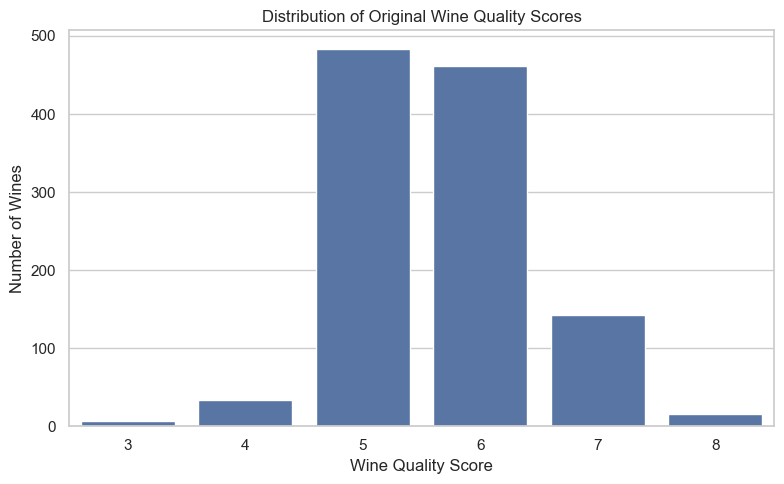

In [7]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality",
    order=sorted(df["quality"].unique())
)

plt.title("Distribution of Original Wine Quality Scores")
plt.xlabel("Wine Quality Score")
plt.ylabel("Number of Wines")
plt.tight_layout()
plt.show()

### Observation

The quality scores are not evenly distributed.

Quality scores 5 and 6 make up most of the dataset, while very low and very
high quality wines are much less common.

This indicates class imbalance in the original target distribution.

# Exploratory Data Analysis (EDA)

## Distribution of Chemical Features

### What?
Examine the distribution of every physicochemical feature in the dataset.

### Why?
Distribution plots help us understand:

- The typical values of each chemical property
- Spread and variability
- Possible skewness
- Potential outliers
- Differences in measurement scales

### How?
We create a histogram with a density curve for every chemical feature.

The dataset contains 11 physicochemical features:

1. Fixed acidity
2. Volatile acidity
3. Citric acid
4. Residual sugar
5. Chlorides
6. Free sulfur dioxide
7. Total sulfur dioxide
8. Density
9. pH
10. Sulphates
11. Alcohol

In [12]:
chemical_features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

print("Number of chemical features:", len(chemical_features))
print("\nChemical features:")
for feature in chemical_features:
    print("-", feature)

Number of chemical features: 11

Chemical features:
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol


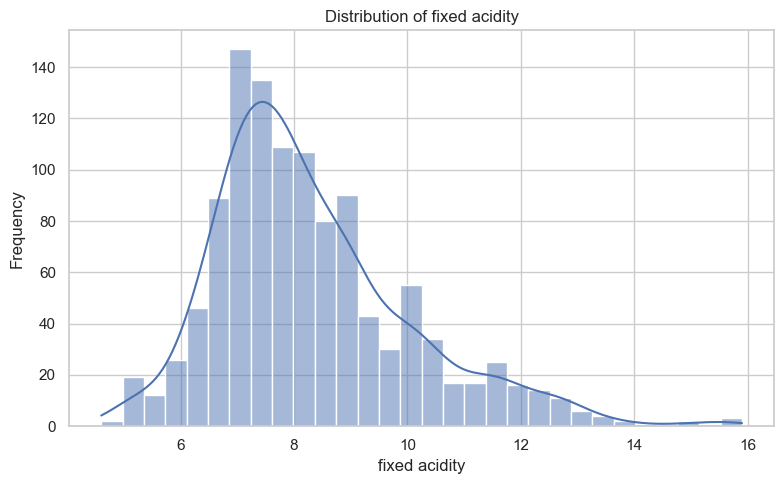

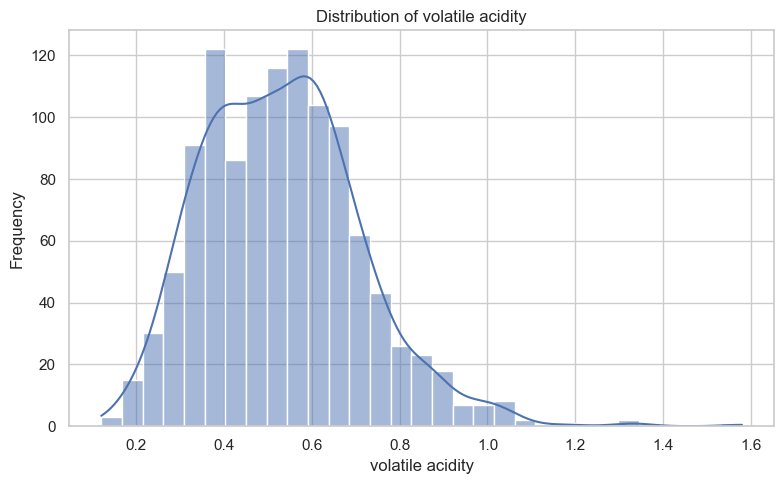

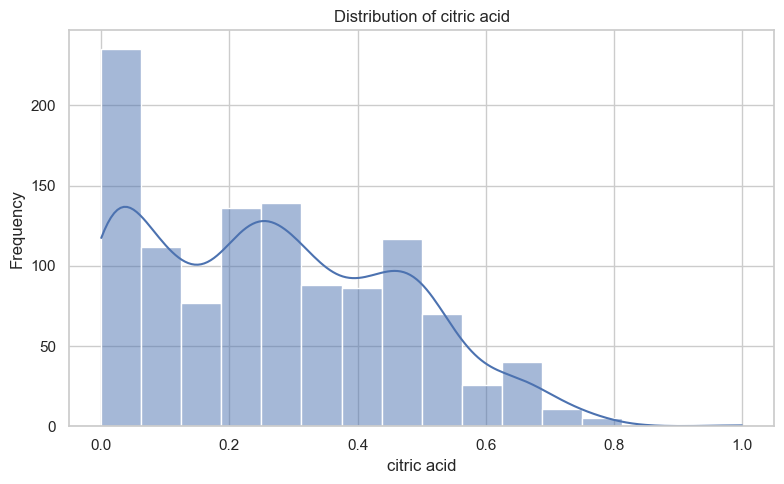

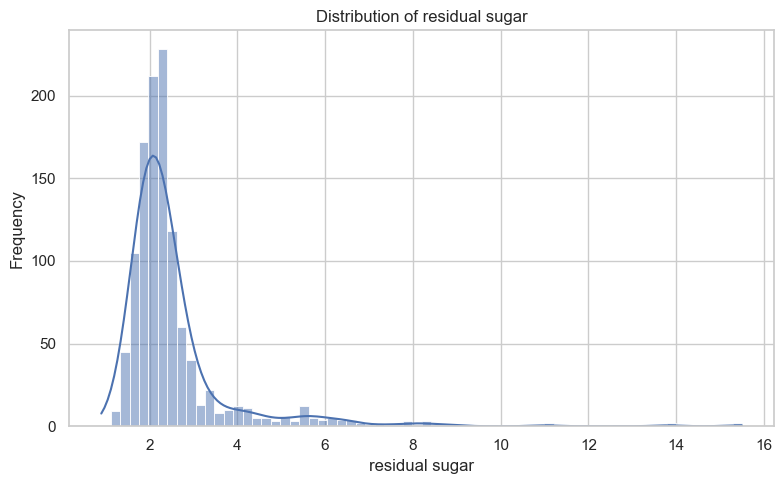

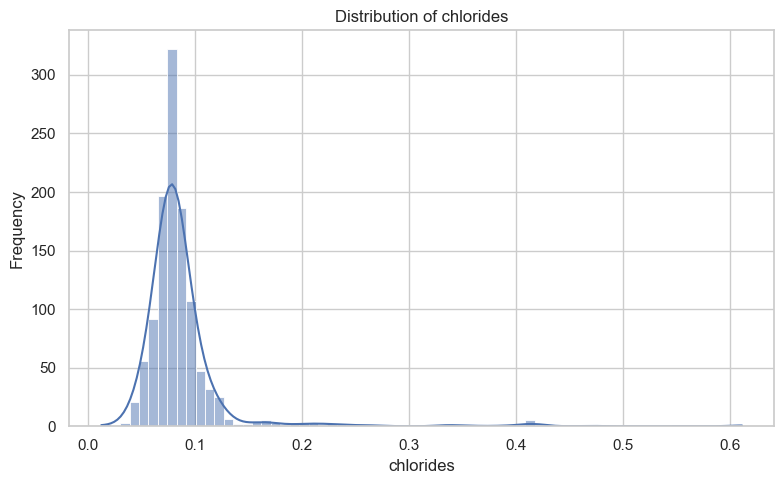

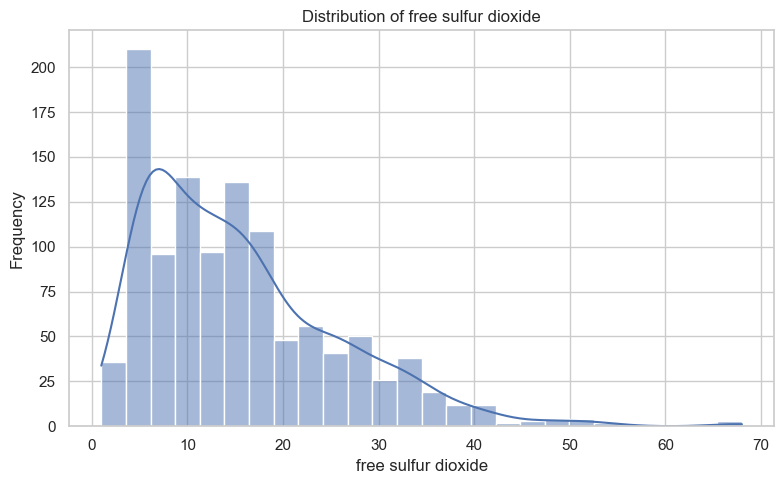

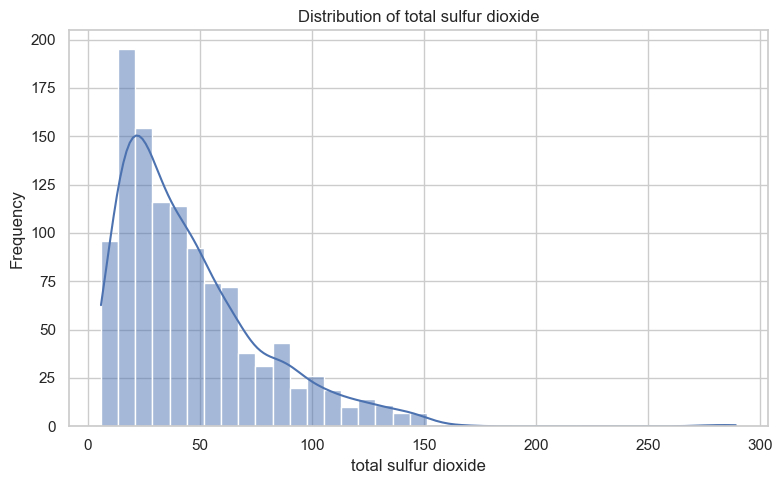

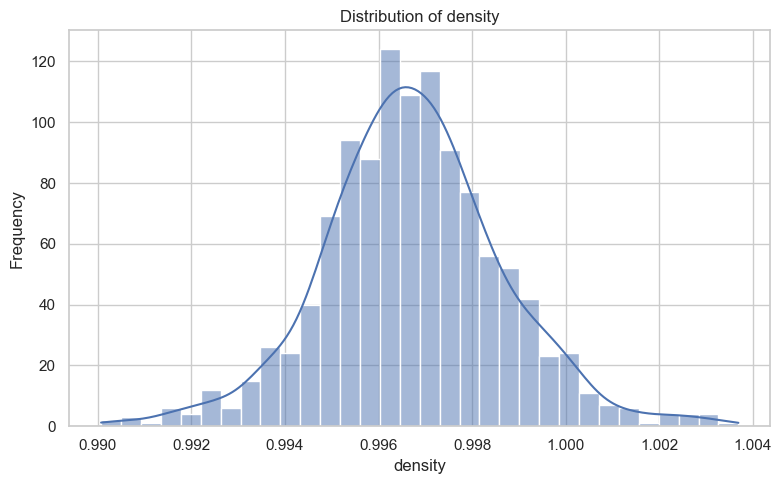

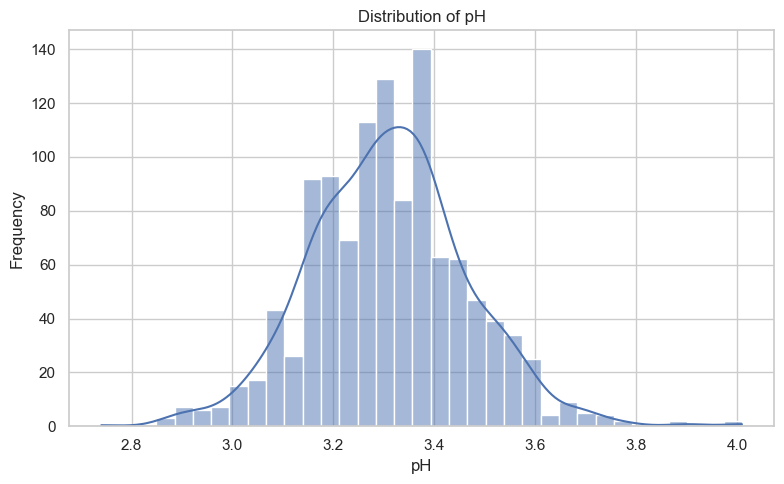

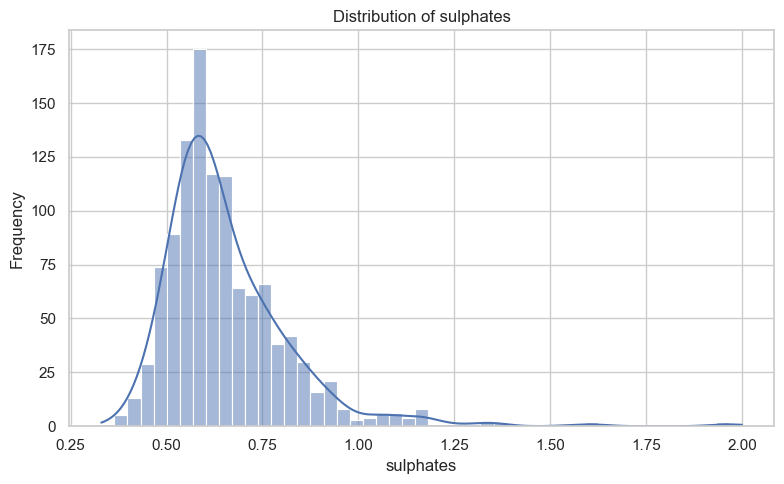

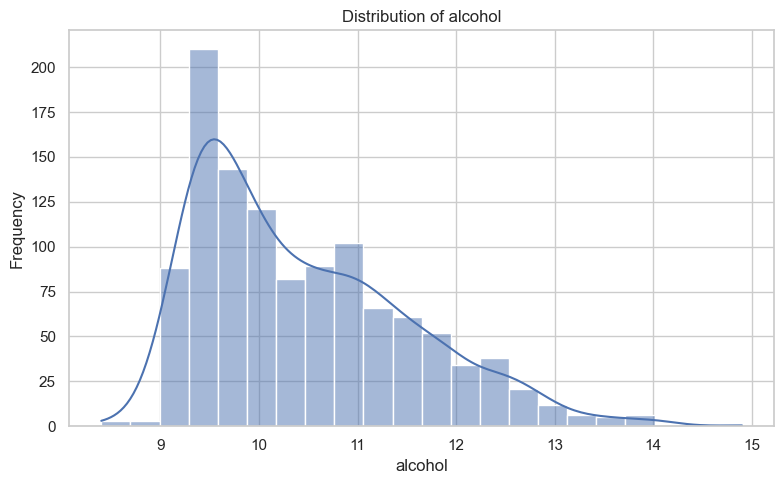

In [13]:
for feature in chemical_features:
    
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df,
        x=feature,
        kde=True
    )
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## Correlation Analysis

### What?
Calculate the correlation between the numerical variables and display the
relationships using a heatmap.

### Why?
Correlation analysis helps identify variables that move together and can
provide useful insight into relationships between the physicochemical
properties and wine quality.

### How?
We calculate the Pearson correlation matrix and visualize it using a
Seaborn heatmap.

In [14]:
correlation_matrix = df[chemical_features + ["quality"]].corr()

display(correlation_matrix)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710


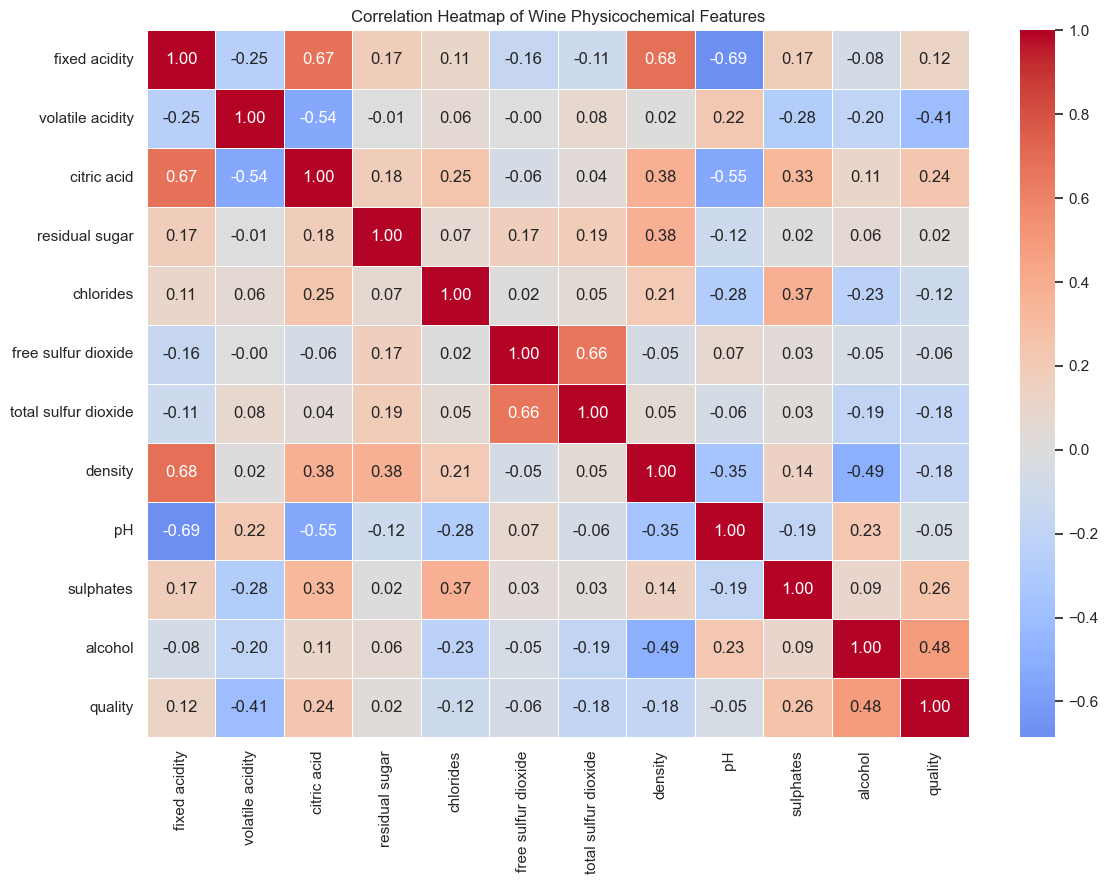

In [15]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Wine Physicochemical Features")
plt.tight_layout()
plt.show()

### EDA Interpretation

The correlation heatmap shows the strength and direction of linear
relationships between the physicochemical variables.

Some variables show stronger relationships with wine quality than others.
However, correlation alone does not determine which features will produce
the best predictions.

The machine learning models will consider the features together when
predicting wine-quality classes.

# Class Imbalance

### What?
Investigate whether some wine-quality scores are underrepresented.

### Why?
Machine learning models can become biased toward classes with many training
examples. If a minority class is poorly represented, a model may achieve
reasonable overall accuracy while performing poorly on that minority class.

### How?
We examine the original quality distribution and later create three broader
quality classes.

The original distribution is:

| Quality | Count |
|--------:|------:|
| 3 | 6 |
| 4 | 33 |
| 5 | 483 |
| 6 | 462 |
| 7 | 143 |
| 8 | 16 |

Quality scores 3 and 8 are especially underrepresented.

To reduce the impact of imbalance, this project:

1. Groups the original scores into three broader classes.
2. Uses stratified train/test splitting.
3. Uses balanced class weights in the classifiers.
4. Uses macro F1 in addition to accuracy when comparing models.

# Feature Engineering

## Convert Quality Scores into Three Classes

### What?
Convert the original numerical wine-quality score into three classification
groups:

- Low
- Medium
- High

### Why?
The original quality scores contain several classes with very few examples.
A three-class problem reduces the extreme sparsity while preserving more
information than a simple binary good/bad classification.

A binary classification would combine many different quality levels into only
two groups.

The three-class approach provides a useful middle ground.

### How?

The grouping is:

- Quality 3–5 → Low
- Quality 6 → Medium
- Quality 7–8 → High

In [16]:
df["quality_group"] = pd.cut(
    df["quality"],
    bins=[0, 5, 6, 10],
    labels=["low", "medium", "high"]
)

print("Quality group distribution:")
display(
    df["quality_group"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

Quality group distribution:


,Count
quality_group,
low,522
medium,462
high,159


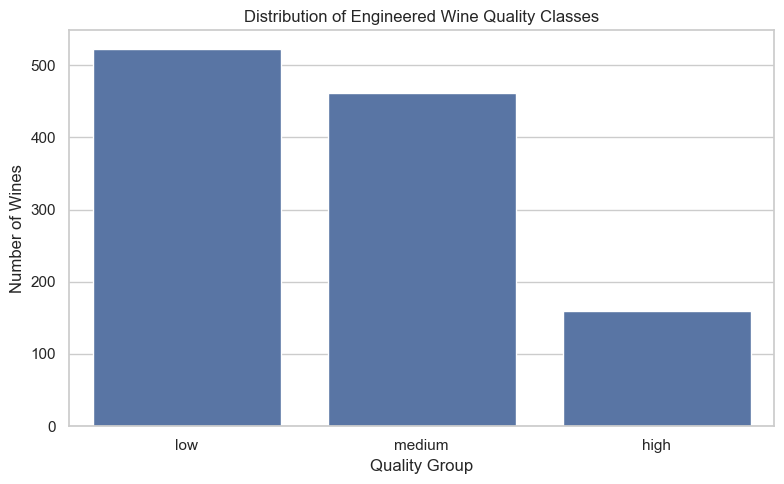

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality_group",
    order=["low", "medium", "high"]
)

plt.title("Distribution of Engineered Wine Quality Classes")
plt.xlabel("Quality Group")
plt.ylabel("Number of Wines")
plt.tight_layout()
plt.show()

### Result

The engineered classes contain:

- Low: 522 wines
- Medium: 462 wines
- High: 159 wines

The High class remains smaller than the other two classes, so class
imbalance is still present.

For this reason, stratification and balanced class weights will be used.

# Prepare Features and Target

### What?
Separate the predictor variables from the target.

### Why?
The original `quality` column contains the answer we are trying to predict.
The engineered `quality_group` is our new target.

The `Id` column is also removed because it is only an identifier and does not
represent a meaningful physicochemical property.

### How?
Use the 11 chemical measurements as predictors and `quality_group` as the
target.

In [18]:
X = df.drop(
    columns=["quality", "quality_group", "Id"]
)

y = df["quality_group"]

print("Feature columns:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Feature columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

X shape: (1143, 11)
y shape: (1143,)


# Train/Test Split

### What?
Split the dataset into training and testing sets.

### Why?
The test set must remain unseen during training so that we can evaluate how
well the models generalize to new data.

Because the quality classes are imbalanced, we use stratification.

### How?
Use an 80/20 train/test split with:

`stratify=y`

This preserves approximately the same proportion of Low, Medium and High
classes in both datasets.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
display(y_train.value_counts().sort_index().to_frame("Count"))

print("\nTesting class distribution:")
display(y_test.value_counts().sort_index().to_frame("Count"))

Training set: (914, 11)
Testing set: (229, 11)

Training class distribution:


,Count
quality_group,
low,417
medium,370
high,127



Testing class distribution:


,Count
quality_group,
low,105
medium,92
high,32


# Train the Classification Models

The task requires three classifiers:

1. Random Forest
2. Stochastic Gradient Descent (SGD)
3. Support Vector Classifier (SVC)

Random Forest is a tree-based ensemble method.

SGD is a linear classifier trained using stochastic gradient descent.

SVC is a support-vector-based classifier that can model nonlinear
relationships using an RBF kernel.

Because SGD and SVC are sensitive to feature scale, StandardScaler is used
inside pipelines for those models.

Balanced class weights are used to give additional importance to the
underrepresented High class.

In [21]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),
    
    "SGD": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SGDClassifier(
            loss="hinge",
            max_iter=2000,
            tol=1e-3,
            random_state=42,
            class_weight="balanced"
        ))
    ]),
    
    "SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            random_state=42,
            class_weight="balanced"
        ))
    ])
}

In [22]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name}: trained successfully")

Random Forest: trained successfully
SGD: trained successfully
SVC: trained successfully


# Model Evaluation

### What?
Evaluate every classifier using:

- Accuracy
- Classification report
- Confusion matrix

### Why?
Accuracy tells us the overall proportion of correct predictions.

The classification report provides:

- Precision
- Recall
- F1-score

for each class.

The confusion matrix shows which quality groups are being confused.

Because the dataset is imbalanced, macro F1 is also considered. Macro F1
gives each class equal importance regardless of its size.

### How?
Generate predictions using the untouched test set.

In [23]:
results = {}
reports = {}
confusion_matrices = {}

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    report = classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
    
    matrix = confusion_matrix(
        y_test,
        y_pred,
        labels=["low", "medium", "high"]
    )
    
    results[name] = {
        "Accuracy": accuracy,
        "Macro F1": float(
            classification_report(
                y_test,
                y_pred,
                output_dict=True,
                zero_division=0
            )["macro avg"]["f1-score"]
        )
    }
    
    reports[name] = report
    confusion_matrices[name] = matrix
    
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(report)
    print("Confusion Matrix:")
    print(matrix)

Random Forest
Accuracy: 0.6900

Classification Report:
              precision    recall  f1-score   support

        high       0.74      0.62      0.68        32
         low       0.75      0.73      0.74       105
      medium       0.61      0.66      0.64        92

    accuracy                           0.69       229
   macro avg       0.70      0.67      0.69       229
weighted avg       0.69      0.69      0.69       229

Confusion Matrix:
[[77 28  0]
 [24 61  7]
 [ 1 11 20]]
SGD
Accuracy: 0.5328

Classification Report:
              precision    recall  f1-score   support

        high       0.30      0.38      0.33        32
         low       0.68      0.69      0.68       105
      medium       0.46      0.41      0.43        92

    accuracy                           0.53       229
   macro avg       0.48      0.49      0.48       229
weighted avg       0.54      0.53      0.53       229

Confusion Matrix:
[[72 27  6]
 [32 38 22]
 [ 2 18 12]]
SVC
Accuracy: 0.6288

Classi

# Visualize Confusion Matrices

### What?
Create a visual confusion matrix for each classifier.

### Why?
The visual representation makes it easier to identify which classes are
being correctly classified and which classes are being confused.

### How?
Plot the confusion-matrix values using a heatmap-style Matplotlib chart

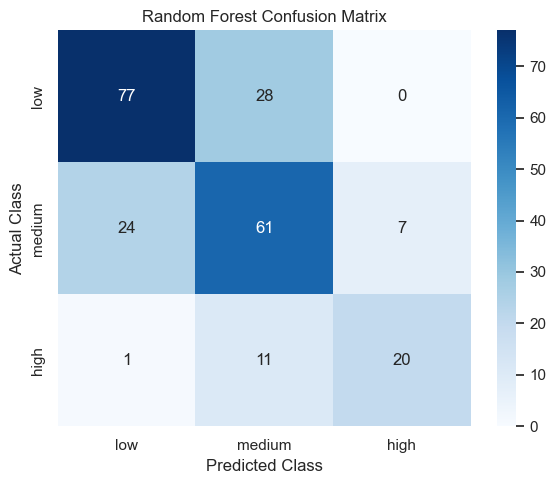

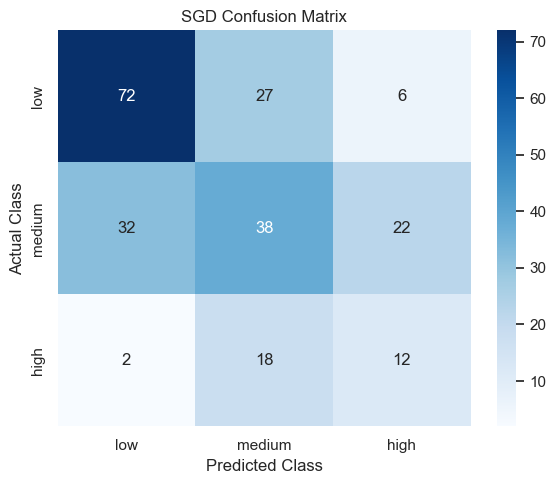

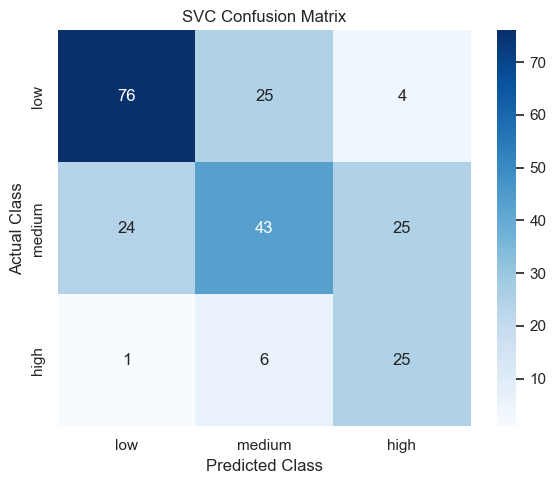

In [24]:
labels = ["low", "medium", "high"]

for name, matrix in confusion_matrices.items():
    
    plt.figure(figsize=(6, 5))
    
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.show()

# Compare the Three Models

### What?
Create a side-by-side comparison of the three classifiers.

### Why?
A comparison table makes it easier to determine which model performed
best.

### How?
Compare both Accuracy and Macro F1.

In [25]:
comparison = pd.DataFrame(results).T

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100
comparison["Macro F1 (%)"] = comparison["Macro F1"] * 100

comparison = comparison[
    ["Accuracy (%)", "Macro F1 (%)"]
].sort_values(
    by="Accuracy (%)",
    ascending=False
)

display(comparison)

,Accuracy (%),Macro F1 (%)
Random Forest,68.995633,68.578137
SVC,62.882096,61.244391
SGD,53.275109,48.336117


<Figure size 800x500 with 0 Axes>

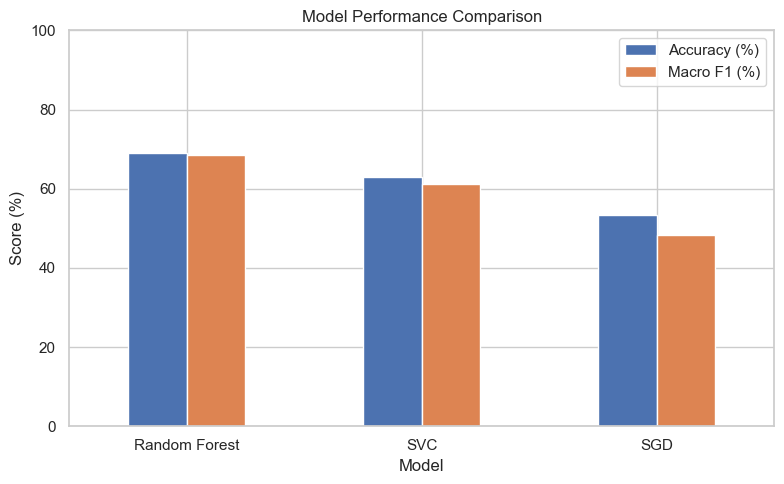

In [26]:
plt.figure(figsize=(8, 5))

comparison[["Accuracy (%)", "Macro F1 (%)"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Random Forest Feature Importance

### What?
Identify the physicochemical variables that were most important to the
Random Forest model.

### Why?
Feature importance helps us understand which measurements contributed most
to the Random Forest's predictions.

### How?
Extract the Random Forest `feature_importances_` values and visualize them
as a horizontal bar chart.

Feature importance is model-specific. It indicates which variables were
useful to the model, it does not prove that a feature causes wine quality.

In [27]:
rf_model = models["Random Forest"]

feature_importance = (
    pd.Series(
        rf_model.feature_importances_,
        index=X.columns
    )
    .sort_values(ascending=False)
)

display(
    feature_importance
    .to_frame("Importance")
)


,Importance
alcohol,0.165310
sulphates,0.132096
volatile acidity,0.116170
citric acid,0.085550
total sulfur dioxide,0.083997
density,0.083409
chlorides,0.076493
fixed acidity,0.071066
pH,0.066834
residual sugar,0.059757


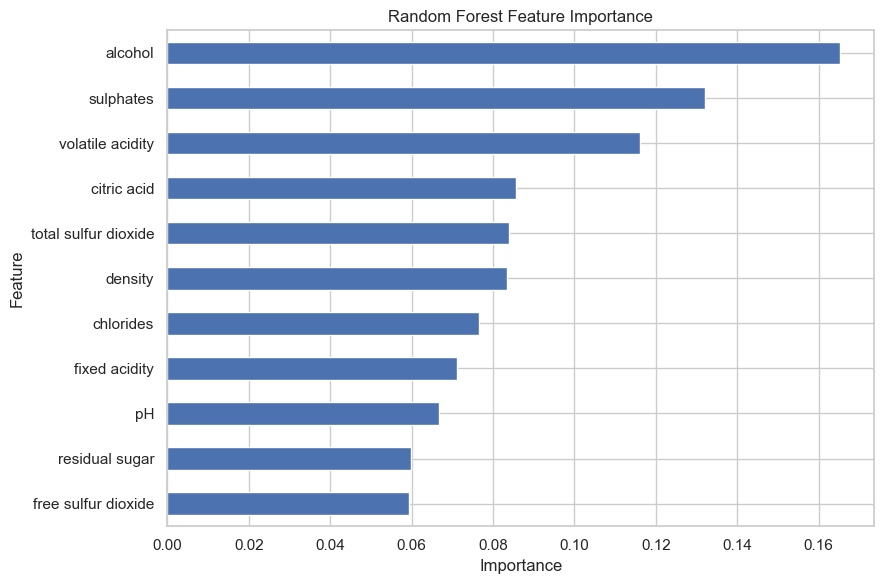

In [28]:
plt.figure(figsize=(9, 6))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [29]:
comparison.to_csv(
    "model_comparison.csv"
)

print("Model comparison saved as model_comparison.csv")

Model comparison saved as model_comparison.csv


In [30]:
df.to_csv(
    "WineQT_processed.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


# Conclusion

The three required classification models were trained and evaluated using
the same stratified test set.

Random Forest achieved the highest overall accuracy and macro F1-score.

### Model ranking

1. Random Forest
2. SVC
3. SGD

Random Forest achieved approximately 69.00% accuracy and a macro F1-score of
approximately 68.58%.

SVC achieved approximately 62.88% accuracy, while SGD achieved approximately
53.28%.

## Recommended Deployment Candidate

Random Forest is the most suitable deployment candidate among the three
models tested in this project.

The reasons are:

- It achieved the highest accuracy.
- It achieved the highest macro F1-score.
- It performed reasonably across Low, Medium and High quality groups.
- It provides feature importance, which makes the model easier to interpret.
- It does not require feature scaling in the same way as SGD and SVC.

However, this should be considered a portfolio-level model rather than a
production-ready system.

Before real-world deployment, the Random Forest model should be evaluated
using additional unseen data, cross-validation and further hyperparameter
tuning.